In [1]:
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision import io
import torchutils as tu
import json
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Загрузка данных
train_dataset = ImageFolder("../data/train", transform=transform_train)
valid_dataset = ImageFolder("../data/valid", transform=transform_val)
test_dataset = ImageFolder("../data/test", transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# Сохраняем список классов
class_names = train_dataset.classes

In [3]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "mps")
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_classes = len(class_names)  # class_names должен быть определён ранее
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# Замораживаем все параметры
for param in model.parameters():
    param.requires_grad = False

# Размораживаем последний слой (fc) и блок layer4
for param in model.fc.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW([
    {'params': model.fc.parameters(), 'lr': 1e-3},
    {'params': model.layer4.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)

num_epochs = 7

def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=7):
    train_losses = []
    val_losses = []
    train_accs = []   # ← добавили
    val_accs = []     # ← уже было, но переименуем для ясности
    
    for epoch in range(epochs):
        # ----- Обучение -----
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)
        
        # ----- Валидация -----
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)
        epoch_val_loss = val_loss / total_val
        epoch_val_acc = correct_val / total_val
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)
        
        print(f"Epoch {epoch+1:2d} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
    
    return train_losses, val_losses, train_accs, val_accs

train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, valid_loader, criterion, optimizer, epochs=num_epochs
)

Epoch  1 | Train Loss: 1.7799 | Train Acc: 0.6070 | Val Loss: 0.5245 | Val Acc: 0.8600
Epoch  2 | Train Loss: 0.4897 | Train Acc: 0.8802 | Val Loss: 0.3122 | Val Acc: 0.9260
Epoch  3 | Train Loss: 0.2605 | Train Acc: 0.9387 | Val Loss: 0.2218 | Val Acc: 0.9300
Epoch  4 | Train Loss: 0.1487 | Train Acc: 0.9677 | Val Loss: 0.1854 | Val Acc: 0.9440
Epoch  5 | Train Loss: 0.0918 | Train Acc: 0.9830 | Val Loss: 0.1647 | Val Acc: 0.9500
Epoch  6 | Train Loss: 0.0642 | Train Acc: 0.9875 | Val Loss: 0.1903 | Val Acc: 0.9360
Epoch  7 | Train Loss: 0.0508 | Train Acc: 0.9906 | Val Loss: 0.1577 | Val Acc: 0.9560


Используется MPS (Apple Silicon GPU)
========== ОБЩИЕ МЕТРИКИ ==========
Общая точность (Accuracy) : 0.9720 (97.20%)
Macro F1-score            : 0.9712
Weighted F1-score         : 0.9712

Полная матрица ошибок сохранена в 'confusion_matrix_full.csv'


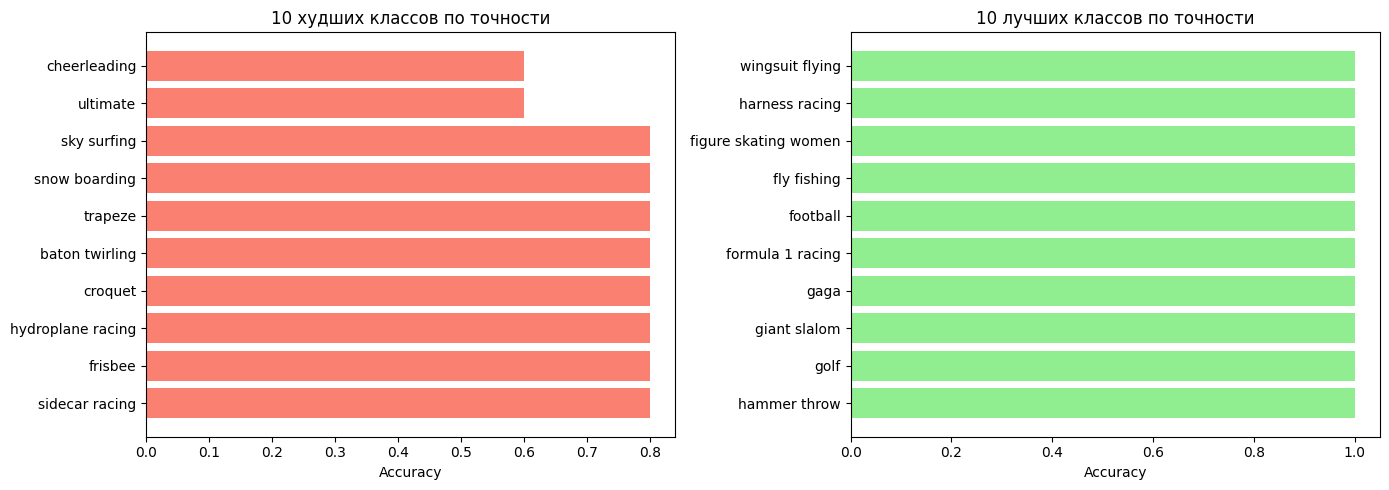


========== ТОП‑10 САМЫХ ЧАСТЫХ ОШИБОК ==========
baton twirling → javelin: 1 раз
cheerleading → football: 1 раз
cheerleading → volleyball: 1 раз
croquet → golf: 1 раз
curling → speed skating: 1 раз
frisbee → figure skating women: 1 раз
hydroplane racing → sailboat racing: 1 раз
sidecar racing → motorcycle racing: 1 раз
sky surfing → snow boarding: 1 раз
snow boarding → giant slalom: 1 раз


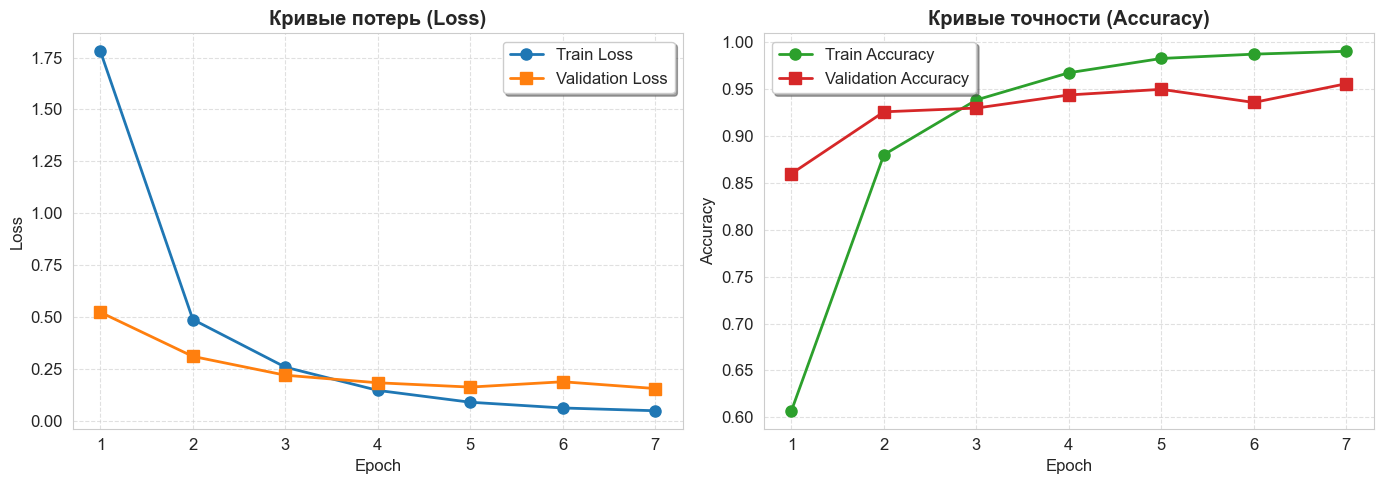

In [11]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# ========== 0. НАСТРОЙКА УСТРОЙСТВА ==========
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Используется MPS (Apple Silicon GPU)")
else:
    device = torch.device('cpu')
    print("MPS не доступен, используется CPU")

# ========== 1. ПОДГОТОВКА МОДЕЛИ И ЗАГРУЗЧИКА ==========
model.eval()                     # режим оценки
model = model.to(device)         # один раз переносим модель на устройство

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        # Переносим данные на то же устройство, что и модель
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)          # прямой проход
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ========== 2. НАЗВАНИЯ КЛАССОВ ==========
class_names = test_loader.dataset.classes

# ========== 3. МЕТРИКИ И МАТРИЦА ОШИБОК ==========
cm = confusion_matrix(y_true, y_pred)
class_acc = cm.diagonal() / cm.sum(axis=1)
overall_acc = np.sum(cm.diagonal()) / np.sum(cm)

report = classification_report(y_true, y_pred, target_names=class_names,
                               output_dict=True, zero_division=0)
f1_macro = report['macro avg']['f1-score']
f1_weighted = report['weighted avg']['f1-score']

print("========== ОБЩИЕ МЕТРИКИ ==========")
print(f"Общая точность (Accuracy) : {overall_acc:.4f} ({overall_acc:.2%})")
print(f"Macro F1-score            : {f1_macro:.4f}")
print(f"Weighted F1-score         : {f1_weighted:.4f}")

# Сохраняем полную матрицу ошибок в CSV
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv('confusion_matrix_full.csv')
print("\nПолная матрица ошибок сохранена в 'confusion_matrix_full.csv'")

# ========== 4. ГРАФИК ТОЧНОСТИ ПО КЛАССАМ ==========
worst_idx = np.argsort(class_acc)[:10]
best_idx = np.argsort(class_acc)[-10:][::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.barh([class_names[i] for i in worst_idx], class_acc[worst_idx], color='salmon')
ax1.set_xlabel('Accuracy')
ax1.set_title('10 худших классов по точности')
ax1.invert_yaxis()

ax2.barh([class_names[i] for i in best_idx], class_acc[best_idx], color='lightgreen')
ax2.set_xlabel('Accuracy')
ax2.set_title('10 лучших классов по точности')
ax2.invert_yaxis()
plt.tight_layout()
plt.show()

# ========== 5. ТОП‑10 САМЫХ ЧАСТЫХ ОШИБОК ==========
errors = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            errors.append((class_names[i], class_names[j], cm[i, j]))
errors.sort(key=lambda x: x[2], reverse=True)

print("\n========== ТОП‑10 САМЫХ ЧАСТЫХ ОШИБОК ==========")
for true, pred, cnt in errors[:10]:
    print(f"{true} → {pred}: {cnt} раз")

# ========== 6. КРИВЫЕ ОБУЧЕНИЯ (если есть данные) ==========
try:
    # Проверяем, существуют ли переменные с историей
    if 'train_losses' in locals() and 'val_losses' in locals() and \
       'train_accs' in locals() and 'val_accs' in locals():
        sns.set_style("whitegrid")
        plt.rcParams['font.size'] = 12
        plt.rcParams['lines.linewidth'] = 2
        plt.rcParams['lines.markersize'] = 8

        fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))

        # График потерь
        epochs = range(1, len(train_losses) + 1)
        ax_loss.plot(epochs, train_losses, 'o-', color='#1f77b4', label='Train Loss', markevery=1)
        ax_loss.plot(epochs, val_losses, 's-', color='#ff7f0e', label='Validation Loss', markevery=1)
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.set_title('Кривые потерь (Loss)', fontweight='bold')
        ax_loss.legend(frameon=True, shadow=True)
        ax_loss.grid(True, linestyle='--', alpha=0.6)

        # График точности
        ax_acc.plot(epochs, train_accs, 'o-', color='#2ca02c', label='Train Accuracy', markevery=1)
        ax_acc.plot(epochs, val_accs, 's-', color='#d62728', label='Validation Accuracy', markevery=1)
        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.set_title('Кривые точности (Accuracy)', fontweight='bold')
        ax_acc.legend(frameon=True, shadow=True)
        ax_acc.grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.show()
    else:
        print("\nПропускаем графики обучения: переменные train_losses, val_losses, train_accs, val_accs не найдены.")
except Exception as e:
    print(f"\nНе удалось построить графики обучения: {e}")

In [12]:
# Сохранение истории обучения (loss, accuracy)
history_df = pd.DataFrame({
    'epoch': list(range(1, len(train_losses)+1)),
    'train_loss': train_losses,
    'val_loss': val_losses,
    'train_acc': train_accs,
    'val_acc': val_accs
})
history_df.to_csv('training_history.csv', index=False)
print("История обучения сохранена в 'training_history.csv'")

# Сохранение списка классов
with open('class_names.txt', 'w') as f:
    for name in class_names:
        f.write(name + '\n')
print("Список классов сохранён в 'class_names.txt'")

История обучения сохранена в 'training_history.csv'
Список классов сохранён в 'class_names.txt'
